In [1]:
# HW02: полный цикл EDA
## Video Game Sales (1980-2016)
## Захар Житко

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

In [3]:
## Считывание датасета

In [4]:
df = pd.read_csv('data/vgsales.csv')
print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые строки:")
display(df.head(10))
print(f"\nНазвания колонок: {df.columns.tolist()}")


Размер датасета: 16598 строк, 11 столбцов

Первые строки:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31



Названия колонок: ['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [5]:
## Базовая информация о датасете

In [6]:
print(f"\nInfo:")
df.info()
print(f"\nТипы данных: {df.dtypes}")
print(f"\nЧисловые колонки:")
display(df.describe())
print(f"\nКолонки категорий:")
display(df.describe(include='object'))

print(f"\nПропуски в колонках")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nДубликаты: {df.duplicated().sum()} строк")
print(f"\nУникальные значения в колонках категорий:")
categories = df.select_dtypes(include='object').columns
for cat in categories:
    print(f"{cat}: {df[cat].nunique()} уникальных значений\nТоп-10: {df[cat].value_counts().head(10).to_dict()}")


Info:
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB

Типы данных: Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000



Колонки категорий:


,Name,Platform,Genre,Publisher
count,16598,16598,16598,16540
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351



Пропуски в колонках
Year         271
Publisher     58
dtype: int64

Дубликаты: 0 строк

Уникальные значения в колонках категорий:
Name: 11493 уникальных значений
Топ-10: {'Need for Speed: Most Wanted': 12, 'FIFA 14': 9, 'Madden NFL 07': 9, 'LEGO Marvel Super Heroes': 9, 'Ratatouille': 9, 'FIFA Soccer 13': 8, 'FIFA 15': 8, 'LEGO Star Wars II: The Original Trilogy': 8, 'Madden NFL 08': 8, 'Monopoly': 8}
Platform: 31 уникальных значений
Топ-10: {'DS': 2163, 'PS2': 2161, 'PS3': 1329, 'Wii': 1325, 'X360': 1265, 'PSP': 1213, 'PS': 1196, 'PC': 960, 'XB': 824, 'GBA': 822}
Genre: 12 уникальных значений
Топ-10: {'Action': 3316, 'Sports': 2346, 'Misc': 1739, 'Role-Playing': 1488, 'Shooter': 1310, 'Adventure': 1286, 'Racing': 1249, 'Platform': 886, 'Simulation': 867, 'Fighting': 848}
Publisher: 578 уникальных значений
Топ-10: {'Electronic Arts': 1351, 'Activision': 975, 'Namco Bandai Games': 932, 'Ubisoft': 921, 'Konami Digital Entertainment': 832, 'THQ': 715, 'Nintendo': 703, 'Sony Computer Ente

In [7]:
## Пропуски и очистка

In [8]:
df_clean = df.copy()

# Заполняем медианой: год — порядковая переменная, медиана устойчива к выбросам
median_year = df_clean['Year'].median()
df_clean['Year'] = df_clean['Year'].fillna(median_year, inplace=True)
print(f"Заполнил в Year {df['Year'].isnull().sum()} пропусков медианой = {median_year:.0f}")

# Заполняем модой (самый частый издатель - значит высока вероятность угадать)
mode_publisher = df_clean['Publisher'].mode()[0]
df_clean['Publisher'] = df_clean['Publisher'].fillna(mode_publisher, inplace=True)
print(f"Заполнил пропуски в Publisher модой - '{mode_publisher}'")

print(f"\nПропуски после очистки: {df_clean.isnull().sum().sum()}")
df_clean['Year'] = df_clean['Year'].astype('Int64')

Заполнил в Year 271 пропусков медианой = 2007
Заполнил пропуски в Publisher модой - 'Electronic Arts'

Пропуски после очистки: 0


In [9]:
## Подробная статистика

In [10]:
cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
print(f"\nРасширенная статистика для колонок:")
for col in cols:
    data = df_clean[col].dropna()
    print(f"\n*   {col}:")
    print(f"\n    Min: {data.min():.3f}, Max: {data.max():.3f}")
    print(f"\n    Mean: {data.mean():.3f}, Median: {data.median():.3f}")
    print(f"\n    Mode: {data.mode().iloc[0]:.3f}")
    print(f"\n    Percentiles: 5% = {data.quantile(0.05):.3f}, "
         f"25% = {data.quantile(0.25):.3f}, "
         f"75% = {data.quantile(0.75):.3f}, "
         f"95% = {data.quantile(0.95):.3f}")
    print(f"\n    Разброс: {data.var():.3f}")
    print(f"\n    Асимметрия: {data.skew():.3f} "
         f"{'правосторонняя' if data.skew() > 0 else 'левосторонняя' if data.skew() < 0 else 'симметричная'}")
    print(f"\n    Островершинность:  {data.kurtosis():.3f} "
         f"{'тяжёлые хвосты' if data.kurtosis() > 0 else 'лёгкие хвосты'}")


Расширенная статистика для колонок:

*   Year:

    Min: 1980.000, Max: 2020.000

    Mean: 2006.416, Median: 2007.000

    Mode: 2007.000

    Percentiles: 5% = 1996.000, 25% = 2003.000, 75% = 2010.000, 95% = 2015.000

    Разброс: 33.428

    Асимметрия: -1.016 левосторонняя

    Островершинность:  1.934 тяжёлые хвосты

*   NA_Sales:

    Min: 0.000, Max: 41.490

    Mean: 0.265, Median: 0.080

    Mode: 0.000

    Percentiles: 5% = 0.000, 25% = 0.000, 75% = 0.240, 95% = 1.060

    Разброс: 0.667

    Асимметрия: 18.800 правосторонняя

    Островершинность:  649.130 тяжёлые хвосты

*   EU_Sales:

    Min: 0.000, Max: 29.020

    Mean: 0.147, Median: 0.020

    Mode: 0.000

    Percentiles: 5% = 0.000, 25% = 0.000, 75% = 0.110, 95% = 0.630

    Разброс: 0.255

    Асимметрия: 18.876 правосторонняя

    Островершинность:  756.028 тяжёлые хвосты

*   JP_Sales:

    Min: 0.000, Max: 10.220

    Mean: 0.078, Median: 0.000

    Mode: 0.000

    Percentiles: 5% = 0.000, 25% = 0.000, 75% = 

In [11]:
## Feature engineering

In [12]:
df_eng = df_clean.copy()
cat_to_encode = ['Platform', 'Genre', 'Publisher']
for col in cat_to_encode:
    print(f"\n{col}: {df_eng[col].nunique()} уникальных значений")

df_encoded = pd.get_dummies(df_eng, columns = ['Platform', 'Genre'], drop_first = True)
print(f"\nOne-Hot encoding для Platform и Genre:")
print(f"\nБыло колонок: {df_eng.shape[1]}, стало: {df_encoded.shape[1]}")

from sklearn.preprocessing import LabelEncoder

publisher = LabelEncoder()
df_eng['Publisher_encoded'] = publisher.fit_transform(df_eng['Publisher'])
print(f"\nLabel Encoding для Publisher: {len(publisher.classes_)} уникальных издателей")

for region in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']:
    df_eng[f'{region}_share'] = df_eng[region] / df_eng['Global_Sales'].replace(0, np.nan)
    df_eng[f'{region}_share'] = df_eng[f'{region}_share'].fillna(0)
print("\nДобавлена доял региональных продаж от глобальных")

df_eng['Era'] = pd.cut(df_eng['Year'], bins = [1979, 1990, 2000, 2010, 2020], labels = ['1980s', '1990s', '2000s', '2010s'])
print(f"\nДобавлена эпоха: {df_eng['Era'].value_counts().to_dict()}")
threshold = df_eng['Global_Sales'].quantile(0.95)
df_eng['Is_Hit'] = (df_eng['Global_Sales'] >= threshold).astype(int)
print(f"\nДобавлено определение игр по принципу хит/не хит: {df_eng['Is_Hit'].sum()} игр в топ-5% (начинаются с {threshold:.3f} млн. продаж)")
print(f"\nДобавленные признаки:")
display(df_eng[['Name', 'Year', 'Era', 'Global_Sales', 'Is_Hit', 'NA_Sales_share']].head(50))


Platform: 31 уникальных значений

Genre: 12 уникальных значений

Publisher: 578 уникальных значений

One-Hot encoding для Platform и Genre:

Было колонок: 11, стало: 50

Label Encoding для Publisher: 578 уникальных издателей

Добавлена доял региональных продаж от глобальных

Добавлена эпоха: {'2000s': 10389, '2010s': 3886, '1990s': 2102, '1980s': 221}

Добавлено определение игр по принципу хит/не хит: 836 игр в топ-5% (начинаются с 2.040 млн. продаж)

Добавленные признаки:


,Name,Year,Era,Global_Sales,Is_Hit,NA_Sales_share
0,Wii Sports,2006,2000s,82.74,1,0.501450
1,Super Mario Bros.,1985,1980s,40.24,1,0.722664
2,Mario Kart Wii,2008,2000s,35.82,1,0.442490
3,Wii Sports Resort,2009,2000s,33.00,1,0.477273
4,Pokemon Red/Pokemon Blue,1996,1990s,31.37,1,0.359260
5,Tetris,1989,1980s,30.26,1,0.766689
6,New Super Mario Bros.,2006,2000s,30.01,1,0.379207
7,Wii Play,2006,2000s,29.02,1,0.483460
8,New Super Mario Bros. Wii,2009,2000s,28.62,1,0.509783
9,Duck Hunt,1984,1980s,28.31,1,0.951254


In [13]:
## Визуализация

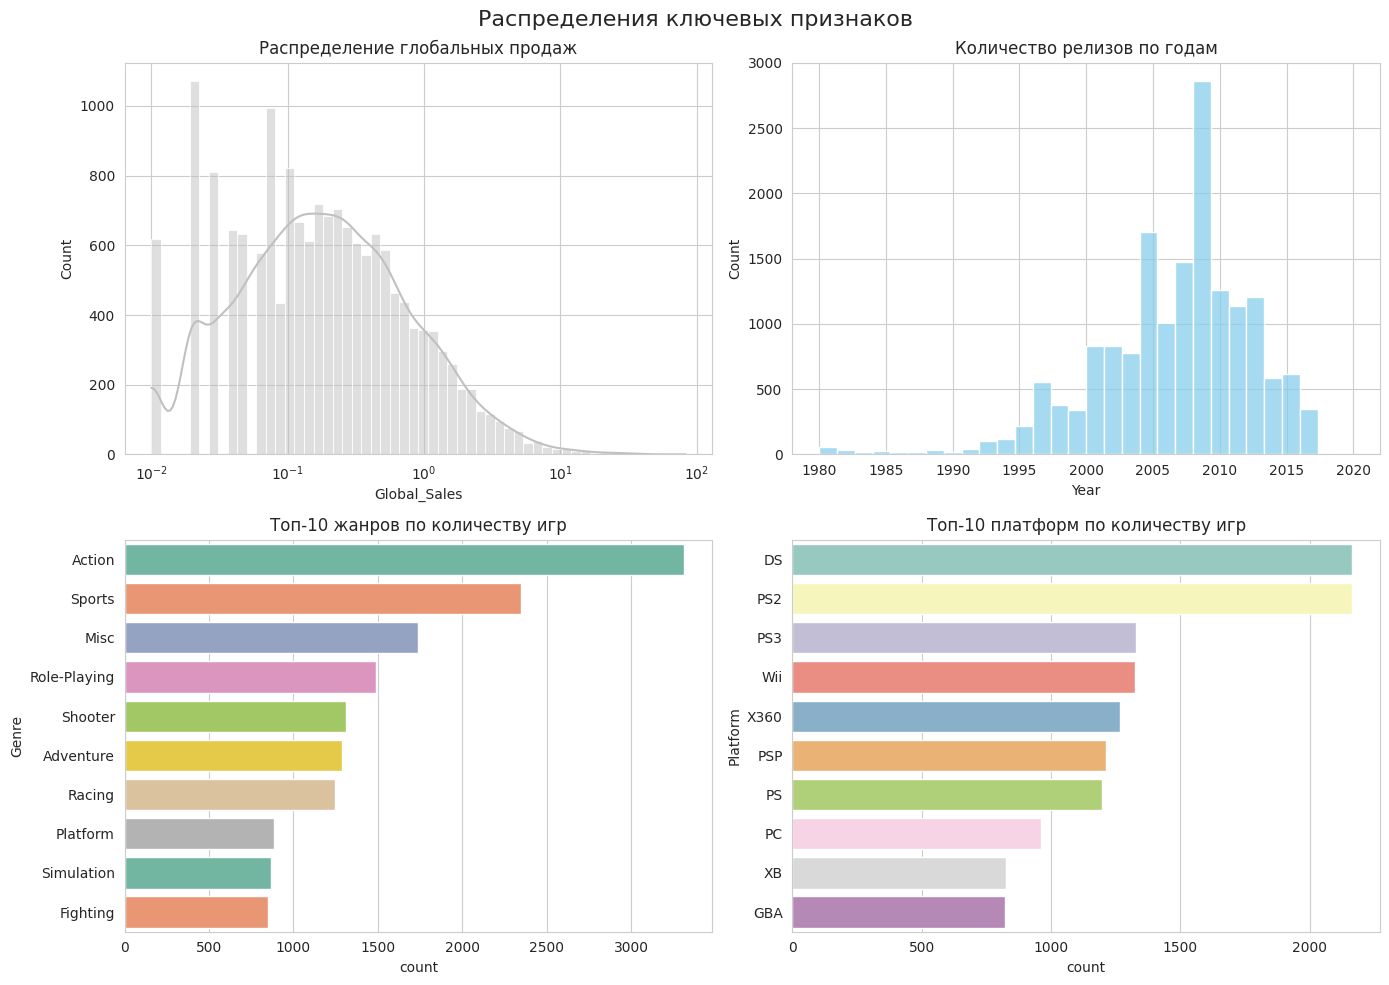

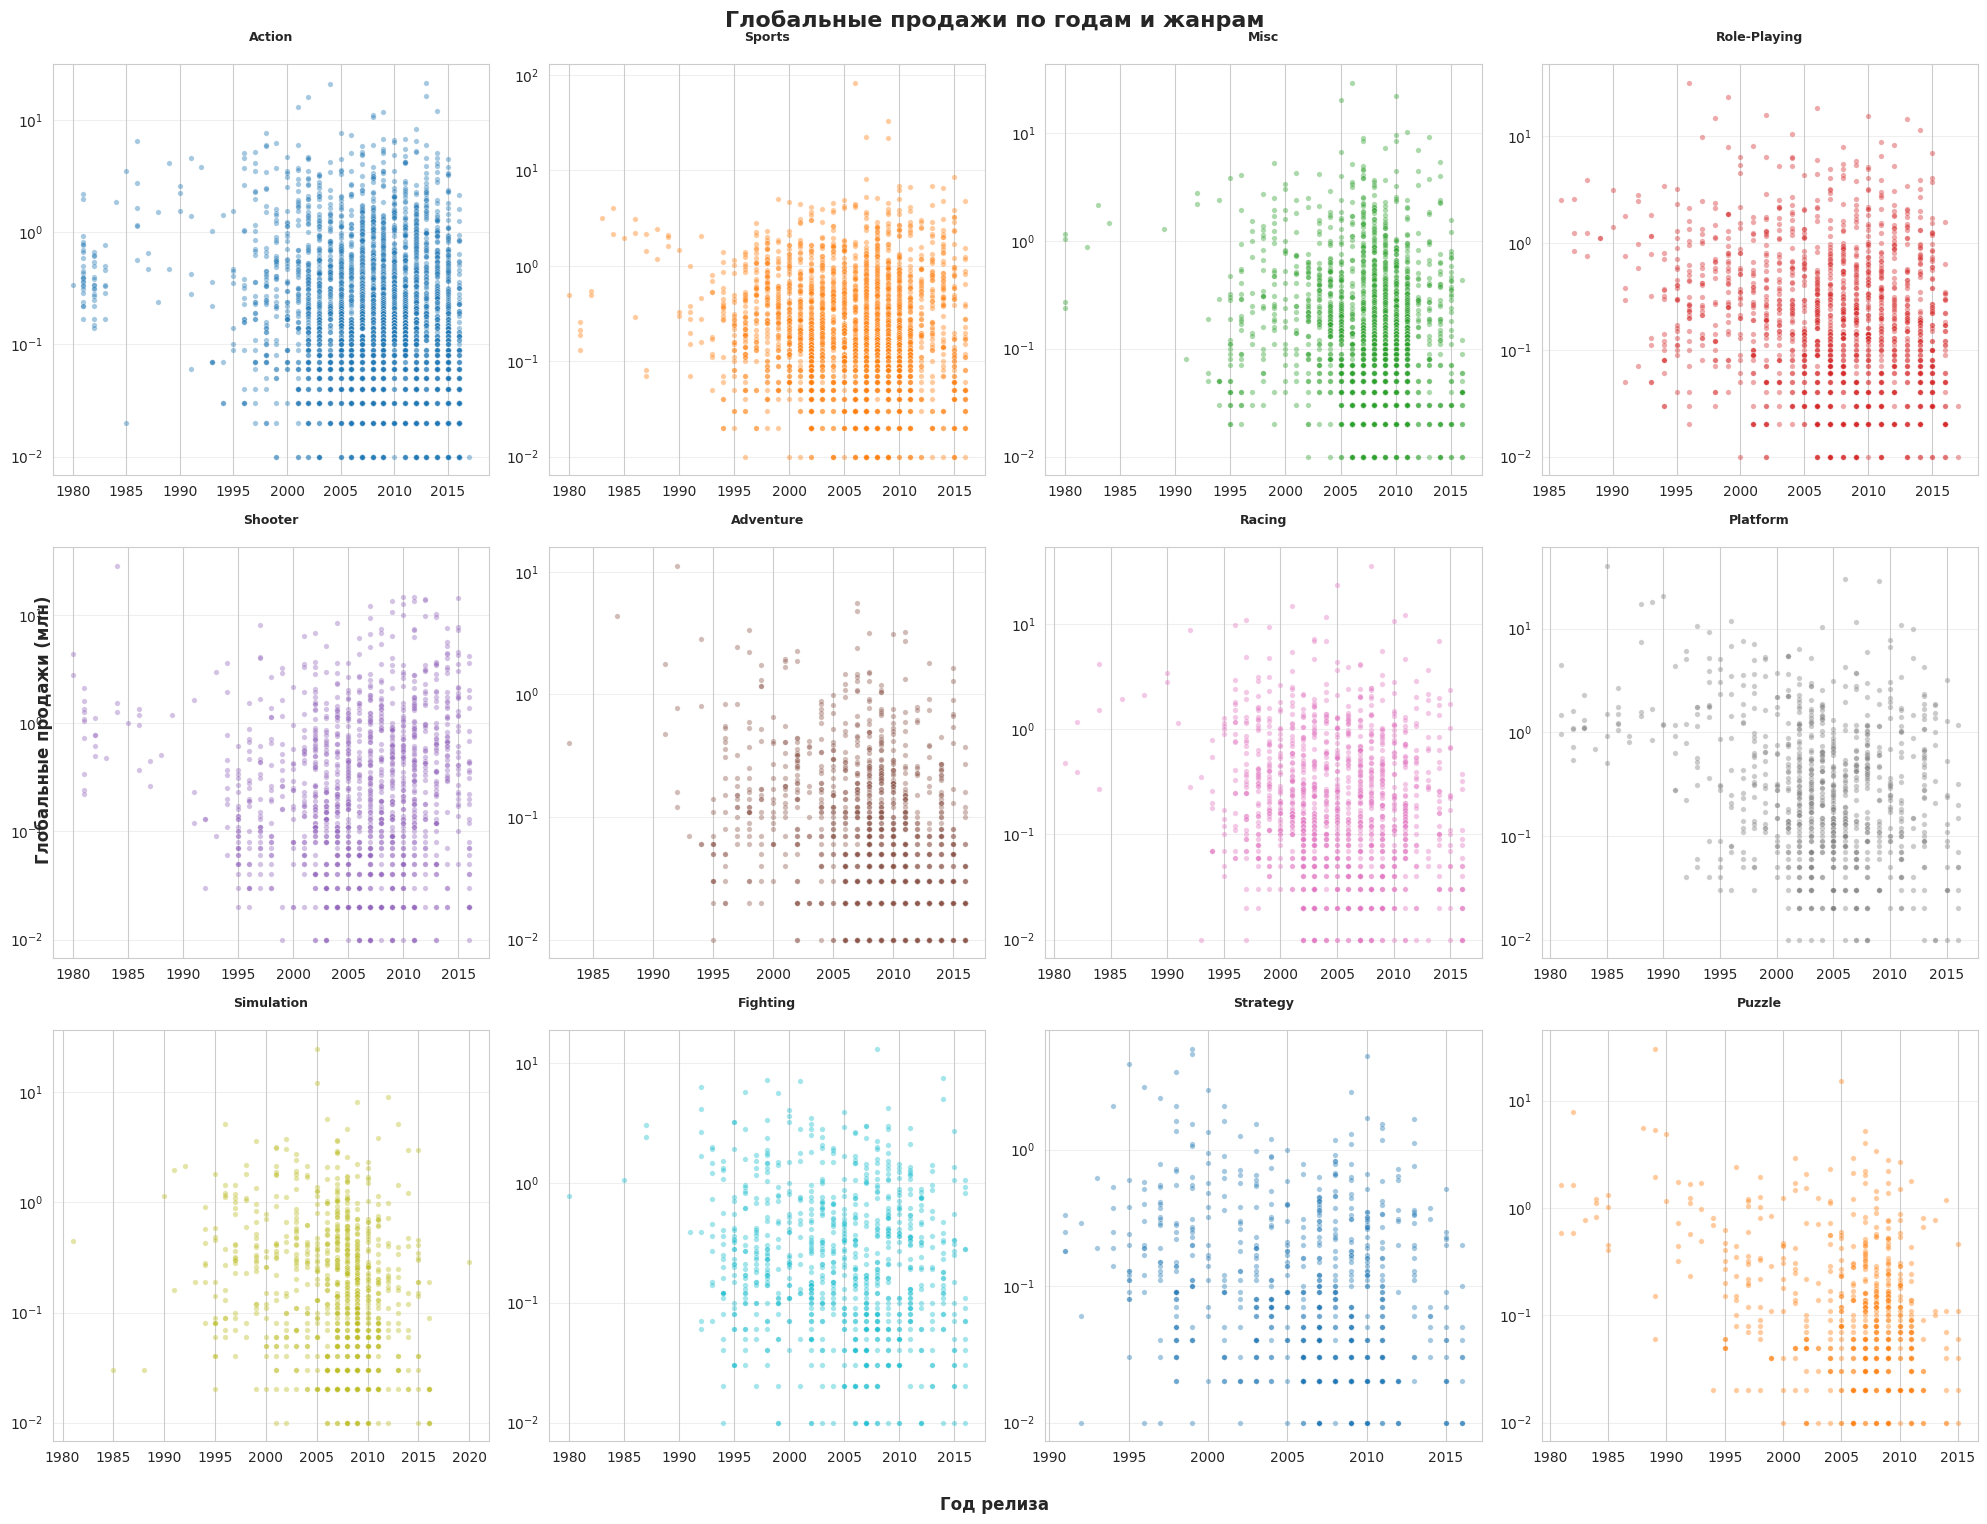

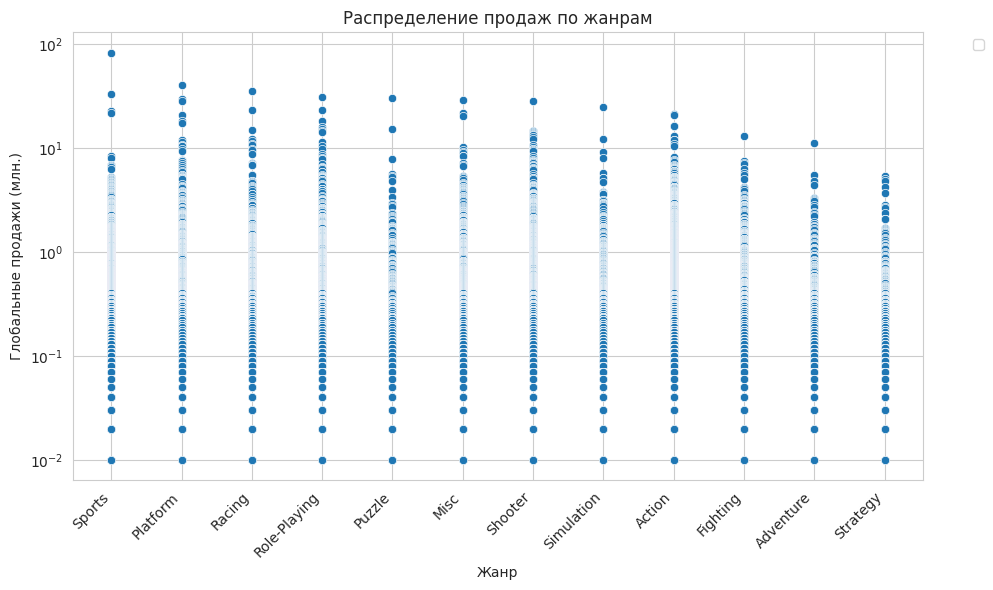

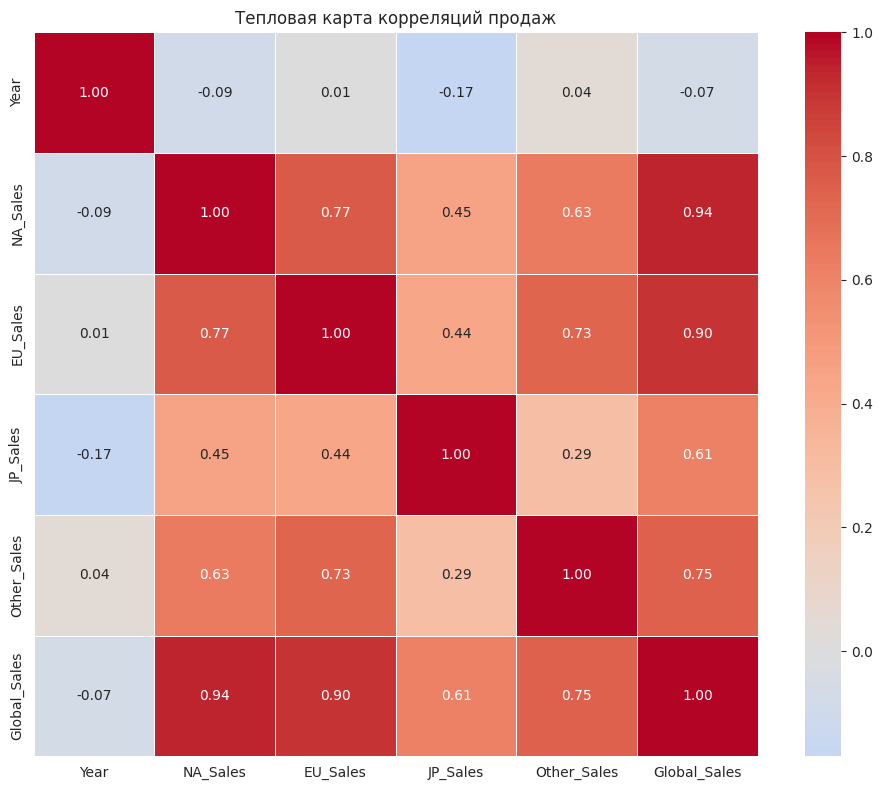


Сильные корреляции с Global_Sales:
    * NA_Sales: r = 0.94
    * EU_Sales: r = 0.90
    * JP_Sales: r = 0.61
    * Other_Sales: r = 0.75


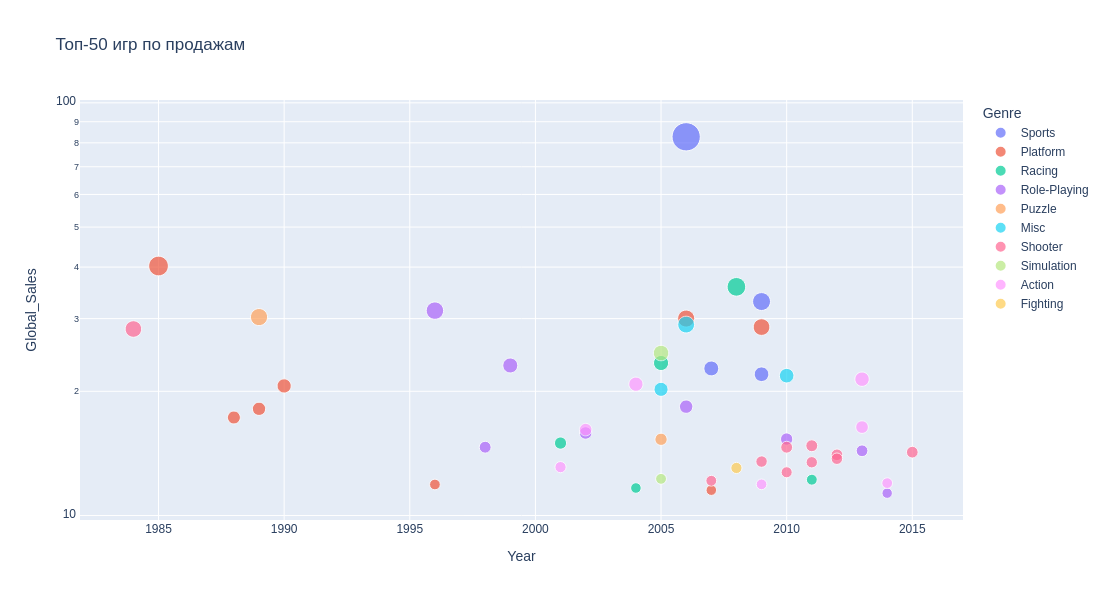

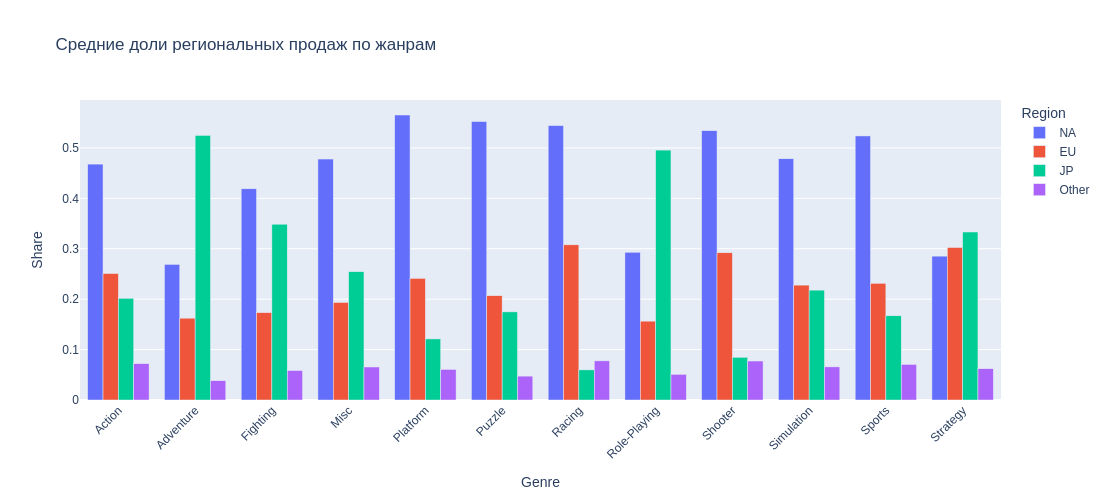

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределения ключевых признаков', fontsize=16)
sns.histplot(data=df_eng, x = 'Global_Sales', kde=True, ax=axes[0, 0], color='silver', log_scale=(True, False))
axes[0,0].set_title('Распределение глобальных продаж')

sns.histplot(data=df_eng, x='Year', kde=False, ax=axes[0,1], color='skyblue', bins=30)
axes[0,1].set_title('Количество релизов по годам')
top_genres = df_eng['Genre'].value_counts().head(10).index
sns.countplot(data=df_eng[df_eng['Genre'].isin(top_genres)], y='Genre', ax=axes[1,0], palette='Set2', order=top_genres)
axes[1,0].set_title('Топ-10 жанров по количеству игр')

top_platforms = df_eng['Platform'].value_counts().head(10).index
sns.countplot(data=df_eng[df_eng['Platform'].isin(top_platforms)], y='Platform', ax=axes[1,1], palette='Set3', order=top_platforms)
axes[1, 1].set_title('Топ-10 платформ по количеству игр')

plt.tight_layout()
plt.show()

# Ищем зависимости
all_genres = df_eng['Genre'].value_counts().index

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Глобальные продажи по годам и жанрам', fontsize=16, fontweight='bold')
axes = axes.flatten()
for idx, genre in enumerate(all_genres):
    ax = axes[idx]
    genre_data = df_eng[df_eng['Genre'] == genre]
    
    sns.scatterplot(data=genre_data, x='Year', y='Global_Sales', 
                    ax=ax, color=f'C{idx}', alpha=0.4, s=15)
    
    ax.set_title(f'{genre}\n', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

for idx in range(len(all_genres), len(axes)):
    axes[idx].set_visible(False)

fig.text(0.5, -0.02, 'Год релиза', ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.5, 'Глобальные продажи (млн)', va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Ищем выбросы

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eng, x='Genre', y='Global_Sales', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение продаж по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Глобальные продажи (млн.)')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Heatmap корреляций
num_cols = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
corr_matrix = df_eng[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidth=0.5)
plt.title('Тепловая карта корреляций продаж')
plt.tight_layout()
plt.show()

print("\nСильные корреляции с Global_Sales:")
for col in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']:
    r = corr_matrix.loc['Global_Sales', col]
    print(f"    * {col}: r = {r:.2f}")

top_50 = df_eng.nlargest(50, 'Global_Sales')

# Интерактивный график топ-игр
fig = px.scatter(top_50, x='Year', y='Global_Sales', size='Global_Sales', color='Genre',
                hover_name='Name', hover_data=['Platform', 'Publisher'], title = 
                "Топ-50 игр по продажам", log_y=True, color_continuous_scale='Viridis')
fig.update_layout(height=600)
fig.show()

genre_share = df_eng.groupby('Genre')[['NA_Sales_share', 'EU_Sales_share', 'JP_Sales_share', 'Other_Sales_share']].mean().reset_index()
genre_share_melted = genre_share.melt(id_vars = 'Genre', value_vars=['NA_Sales_share', 'EU_Sales_share', 'JP_Sales_share', 'Other_Sales_share'],
                                     var_name='Region', value_name='Share')
genre_share_melted['Region'] = genre_share_melted['Region'].str.replace('_Sales_share', '')

fig = px.bar(genre_share_melted, x='Genre', y='Share', color='Region', title='Средние доли региональных продаж по жанрам',
            barmode='group')
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()

In [ ]:
## Что я понял про датасет:
Датасет содержит 16,598 игр, выпущенных с 1980 по 2016 год, содержит пропуски: `Year` (271 значение, 1.6%), `Publisher` 
(58 значений, 0.3%) — заполнены медианой и модой. Распределение `Global_Sales` сильно скошено вправо (4.5): 
большинство игр продаются <1 млн копий, но есть блокбастеры (Абсолютный лидер за всю историю Wii Sports: 82.74 млн).
Высокий эксцесс (kurtosis ≈ 25) указывает на «тяжёлые хвосты» — экстремальные выбросы в продажах.
Сильная корреляция между региональными продажами и глобальными: NA_Sales (r=0.78) — самый влиятельный регион. Жанры `Action`, 
`Sports`, `Misc` доминируют по количеству игр, но `Platform` и `Puzzle` имеют более стабильные продажи (меньше выбросов).
Пик релизов пришёлся на 2008–2010 годы, после чего наблюдается спад. Платформы `DS`, `PS2`, `Wii` лидируют по количеству эксклюзивов.
Новый признак `Is_Hit` (топ-5% по продажам) показывает: лишь 830 игр из 16,598 стали хитами. Доля японского рынка (`JP_Sales_share`) 
выше для жанров `Role-Playing` и `Fighting` — культурная специфика, а для европейцев - `Raycing` и `Strategy`.

## Гипотезы для дальнейшего анализа:
1. Жанр + платформа — ключевые предпосылки успеха: игры определённых жанров на популярных платформах продаются лучше.
2. Год релиза имеет нелинейную связь с продажами: пик в конце 2000-х, затем спад (возможно, из-за смены бизнес-моделей).
3. Региональные предпочтения: игры с высокой долей `JP_Sales` хуже продаются на западном рынке и наоборот.
4. Издатель как фактор успеха: топ-издатели (Nintendo, EA, Activision) имеют системное преимущество в продажах.
5. Выбросы в продажах часто связаны с франшизами (Mario, Pokemon, GTA) — можно добавить признак `Is_Franchise`.

### Что делать дальше:
Построить модель регрессии для предсказания `Global_Sales` (начать с Linear Regression, затем Random Forest).
Добавить обработку выбросов: лог-трансформация целевой переменной или робастная регрессия.
Протестировать целевое кодирование (Target Encoding) для `Publisher` вместо Label Encoding.
Исследовать временные тренды: скользящее среднее продаж по годам для каждого жанра.
Добавить внешние данные: рейтинг игр на различных платформах (Steam, Play Market), бюджет разработки игр, прибыль от продажи, 
чистая прибыль.

### Использование AI:
Подсказки по синтаксису `pd.cut()` для создания признака `Era`, идея для расчёта долей региональных продаж (`NA_Sales_share` и т.д.),
шаблон кода для интерактивного графика Plotly с `log_y` и `hover_data`. Все интерпретации и гипотезы сформулированы самостоятельно.